# Neural Radiance Fields (NeRF): A Minimal Implementation
In this notebook, we will implement a minimal version of Neural Radiance Fields (NeRF) proposed in:
> Mildenhall, B., Srinivasan, P. P., Tancik, M., Barron, J. T., Ramamoorthi, R., & Ng, R. (2020).
NeRF: Representing Scenes as Neural Radiance Fields for View Synthesis.
ECCV 2020.

In [1]:
# PyTorch NeRF Implementation
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import clear_output

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")


Using device: cuda


# Dataset - Pixels as Rays
In this tutorial, we use a small synthetic dataset provided in the file "tiny_nerf_data.npz". This dataset is a simplified version of the data used in the original NeRF paper and contains everything needed to train a minimal model.
- images: [N, H, W, 3] Array with N images of shape 100x100 pixels with three color chanels (RGB).
- A single scalar representing the focal length of the camera in pixels.  This defines the intrinsic calibration matrix as
$$
\mathbf{K} =
\begin{bmatrix}
f & 0 & c_x \\
0 & f & c_y \\
0 & 0 & 1
\end{bmatrix}
$$
where $f$ is the focal length in pixels and $(c_x, c_y)$ is the principal point, here we consider $c_x = 0.5W$ and $c_y = 0.5H$.
- poses: [N, 4, 4] Array of Camera-to-World (C2W) transformation matrices. Each matrix $\mathbf{T}$ describes the camera's position and orientation in 3D space:

$$
\mathbf{T} =
\begin{bmatrix}
R & \mathbf{t} \\
\mathbf{0}^\top & 1
\end{bmatrix}
$$

where the top-left $3 \times 3$ block $R$ represents the rotation matrix, the top-right $3 \times 1$ vector $\mathbf{t}$ represents the translation,  and the last row enforces homogeneous coordinates. 

The parameters form the Pinhole Camera model as shown in the following figure:

![Title](pinhole_model.webp)

Using this model, a scene view can be formed by projecting 3D points into the image plane using a perspective transformation.


$$s \begin{bmatrix} 
u \\ 
v \\ 
1 
\end{bmatrix} = 
K
[ R \mid \mathbf{t} ]
\begin{bmatrix} 
X \\ 
Y \\ 
Z \\ 
1 
\end{bmatrix}$$


Let's read this dataset

In [2]:
data = np.load('tiny_nerf_data.npz')
images = torch.from_numpy(data['images']).float().to(device)
poses = torch.from_numpy(data['poses']).float().to(device)
focal = float(data['focal'])
H, W = images.shape[1:3]
K = torch.Tensor([[focal, 0, W/2.0], [0, focal, H/2.0], [0, 0, 1]]).float().to(device)
print(f"dataset: Images shape={images.shape}, Poses shape={poses.shape}, Intrinsics={K.shape}")

dataset: Images shape=torch.Size([106, 100, 100, 3]), Poses shape=torch.Size([106, 4, 4]), Intrinsics=torch.Size([3, 3])


Let's also split and visualise our the dataset

training split: torch.Size([100, 100, 100, 3]), training pose shape: torch.Size([100, 4, 4])
test split: torch.Size([6, 100, 100, 3]), test pose shape: torch.Size([6, 4, 4])


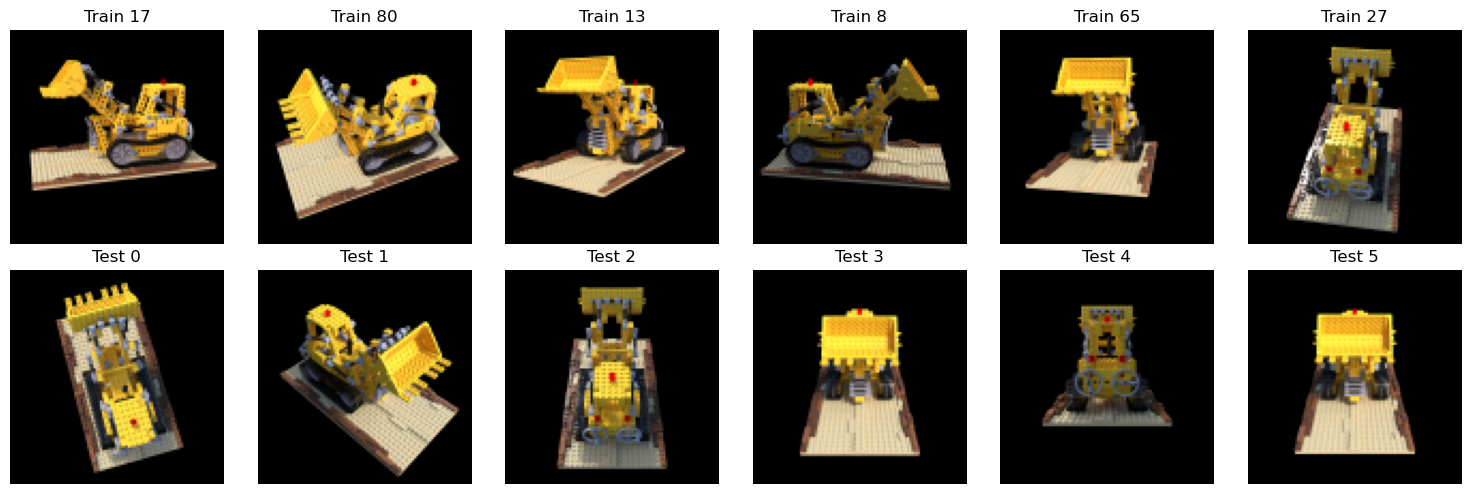

In [3]:
# spliting the dataset into training and test sets
test_images, test_poses = images[100:], poses[100:]
train_images, train_poses = images[:100], poses[:100]
print(f"training split: {train_images.shape}, training pose shape: {train_poses.shape}")
print(f"test split: {test_images.shape}, test pose shape: {test_poses.shape}")

# Create a figure with 2 rows and 6 columns
fig, axes = plt.subplots(2, 6, figsize=(15, 5))

# Plot 6 training images in the first row
for i, sample_idx in enumerate(np.random.randint(0, train_images.shape[0], 6)):    
    axes[0, i].imshow(train_images[sample_idx].cpu().numpy())
    axes[0, i].set_title(f'Train {sample_idx}')
    axes[0, i].axis('off')

# Plot 6 test images in the second row
for i in range(6):
    axes[1, i].imshow(test_images[i].cpu().numpy())
    axes[1, i].set_title(f'Test {i}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

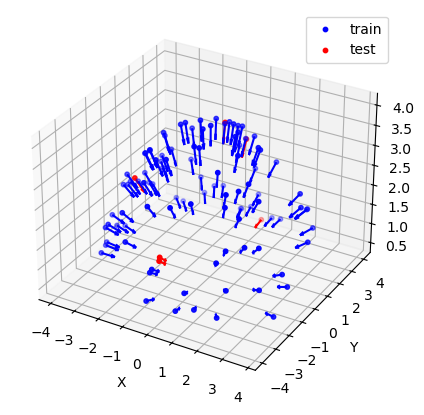

In [4]:
train_centers = train_poses[:, :3, 3].detach().cpu().numpy()
test_centers = test_poses[:, :3, 3].detach().cpu().numpy()

train_dirs = train_poses[:, :3, 2].detach().cpu().numpy()
test_dirs = test_poses[:, :3, 2].detach().cpu().numpy()

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(train_centers[:, 0], train_centers[:, 1], train_centers[:, 2], c="blue", s=10, label="train")
ax.scatter(test_centers[:, 0], test_centers[:, 1], test_centers[:, 2], c="red", s=10, label="test")

ax.quiver(
    train_centers[:, 0], train_centers[:, 1], train_centers[:, 2],
    -train_dirs[:, 0], -train_dirs[:, 1], -train_dirs[:, 2],
    length=0.5, color="blue", normalize=True
)
ax.quiver(
    test_centers[:, 0], test_centers[:, 1], test_centers[:, 2],
    -test_dirs[:, 0], -test_dirs[:, 1], -test_dirs[:, 2],
    length=0.5, color="red", normalize=True
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.legend()
plt.show()

NeRF learns a 3D scene by minimizing the error between rendered pixels and ground truth images. We treat our dataset $\mathcal{D}$ of $N$ posed images as a flattened "pool" of $M$ independent pixels, optimizing the network weights $\Theta$:

$$\min_{\Theta} \sum_{k=1}^{M} \| C_\theta(p_k) - I(p_k) \|^2$$

- $C_{\theta}(p)$: Predicted color for pixel $p$.
- $I(p)$: Ground truth RGB color.
    
Predicting color from 2D coordinates alone is ill-posed; we must bridge the gap to 3D by representing each pixel as a **Ray**. Given intrinsics $K$ and camera-to-world pose $[R \mid \mathbf{t}]$, we define the ray $r(t) = \mathbf{o} + t \mathbf{d}$ as:

$$\begin{aligned} \mathbf{o} &= \mathbf{t} \\ \mathbf{d}_{\text{cam}} &= \begin{bmatrix} (u - c_x)/f_x & (v - c_y)/f_y & 1 \end{bmatrix}^\top \\ \mathbf{d} &= R \, \mathbf{d}_{\text{cam}} \\ \end{aligned}$$

Parameters:

- Origin ($\mathbf{o}$): Camera position in world space (\mathbf{t}).
- Direction ($\mathbf{d}$): Local camera vector rotated into world space.
-  $t$ represents the distance (or "time") traveled along the ray starting from the camera origin


To implement our objective function, we need a dataloader that provides batches of **ray origins**, **ray directions**, and **target colors** from our posed images. Let's start by computing all rays given an posed image...
    

In [5]:
def get_rays(K, c2w, H, W):
    """
    TODO: Get ray origin, direction to each image pixels based on camera pose
    """
    # 1. Create pixel grid, x first
    i, j = torch.meshgrid(
        torch.arange(W, dtype=torch.float32, device=c2w.device),
        torch.arange(H, dtype=torch.float32, device=c2w.device),
        indexing='xy'
    )

    # 2. Get directions in camera coordinates
    # We use the explicit K components: (u - cx)/fx, (v - cy)/fy
    # NeRF typically uses -1 for the z-axis (looking "into" the screen)
    dirs = torch.stack([
        (i - K[0, 2]) / K[0, 0],
        -(j - K[1, 2]) / K[1, 1], # Negated to flip y-axis for standard NeRF orientation
        -torch.ones_like(i)
    ], dim=-1)

    # 3. Transform directions to world space
    # (H, W, 3) @ (3, 3) -> (H, W, 3)
    rays_d = dirs @ c2w[:3, :3].T
    
    # 4. Origin is the translation vector of the camera-to-world matrix
    rays_o = c2w[:3, -1].expand(rays_d.shape)
    return rays_o, rays_d

rays_o_i, rays_d_i = get_rays(K, train_poses[0], H, W)
rays_o_j, rays_d_j = get_rays(K, train_poses[10], H, W)
print(f"rays_o_i shape: {rays_o_i.shape}, rays_d_i shape: {rays_d_i.shape}")
print(f"rays_o_j shape: {rays_o_j.shape}, rays_d_j shape: {rays_d_j.shape}")

rays_o_i shape: torch.Size([100, 100, 3]), rays_d_i shape: torch.Size([100, 100, 3])
rays_o_j shape: torch.Size([100, 100, 3]), rays_d_j shape: torch.Size([100, 100, 3])


Now that, we know how to compute rays let's create our **NeRFDataset** and **Dataloader**...

In [6]:
class NeRFDataset(torch.utils.data.Dataset):
    def __init__(self, images, poses, intrinsic):
        """
        images: (N_images, H, W, 3)
        poses: (N_images, 4, 4)
        """
        # class attributes
        self.images, self.poses, self.intrinsic = images, poses, intrinsic        
        self.H, self.W = images.shape[1], images.shape[2]
        self.all_rays_o, self.all_rays_d, self.all_rays_rgbs = [], [], [] 

        # compute all rays
        for i in range(len(images)):
            rays_o, rays_d = get_rays(self.intrinsic, self.poses[i], self.H, self.W)
            self.all_rays_o.append(rays_o.reshape(-1, 3))            
            self.all_rays_d.append(rays_d.reshape(-1, 3))            
            self.all_rays_rgbs.append(images[i].reshape(-1, 3))

        # Concatenate all rays from all images
        self.all_rays_o = torch.cat(self.all_rays_o, dim=0)
        self.all_rays_d = torch.cat(self.all_rays_d, dim=0)
        self.all_rays_rgbs = torch.cat(self.all_rays_rgbs, dim=0)

    def __len__(self):
        return len(self.all_rays_o)

    def __getitem__(self, idx):
        return (self.all_rays_o[idx], self.all_rays_d[idx], self.all_rays_rgbs[idx])

train_dataloader = torch.utils.data.DataLoader(NeRFDataset(train_images, train_poses, K), batch_size=1024, shuffle=True)

Let's visualize some sampled rays...

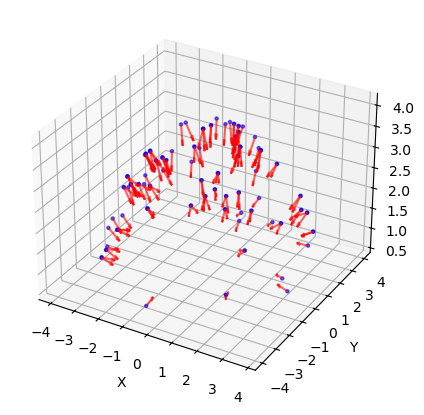

In [7]:
rays_o, rays_d, rays_rgb = next(iter(train_dataloader))
n = min(128, rays_o.shape[0])
rays_o = rays_o[:n].cpu().numpy()
rays_d = rays_d[:n].cpu().numpy()

fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(rays_o[:, 0], rays_o[:, 1], rays_o[:, 2], s=5, c="blue", alpha=0.6)
ax.quiver(
    rays_o[:, 0], rays_o[:, 1], rays_o[:, 2],
    rays_d[:, 0], rays_d[:, 1], rays_d[:, 2],
    length=0.5, normalize=True, color="red", alpha=0.6
)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
plt.show()

# Model - Neural Scene Representation

NeRF represents a scene as a continuous radiance field $F_{\mathbf{\theta}}$ that assigns:

<div style="display: flex; justify-content: center;">
    <img src="nerf_model.png" width="400">
</div>


- a **volume density** $\sigma$ (which encodes how likely a ray is to terminate at that location), and  
- an **emitted color** $\mathbf{c} = (r,g,b)$ (radiance),

to every 3D point $\mathbf{x} = (x,y,z)$ observed from a viewing direction $\mathbf{d} \in \mathbb{R}^3$.


### Positional Encoding

To allow the network to represent **high-frequency details**, each input is mapped to a higher-dimensional space using **positional encoding**:

$$
\gamma(\mathbf{x}) = \Big[
\mathbf{x}, \sin(2^0 \pi \mathbf{x}), \cos(2^0 \pi \mathbf{x}), \dots, \sin(2^{L-1} \pi \mathbf{x}), \cos(2^{L-1} \pi \mathbf{x})
\Big]
$$

$$
\gamma(\mathbf{d}) = \Big[
\mathbf{d}, \sin(2^0 \pi \mathbf{d}), \cos(2^0 \pi \mathbf{d}), \dots, \sin(2^{L-1} \pi \mathbf{d}), \cos(2^{L-1} \pi \mathbf{d})
\Big]
$$

- $L$ = number of frequency bands  
- $\gamma(\mathbf{x})$ and $\gamma(\mathbf{d})$ are used as inputs to the network instead of raw coordinates  
- This allows the MLP to model **high-frequency variations** in both geometry and appearance


Formally, the network becomes:

$$
F_{\mathbf{\theta}} : (\gamma(\mathbf{x}), \gamma(\mathbf{d})) \mapsto (\sigma, \mathbf{c})
$$

Here:

- $\mathbf{x} \in \mathbb{R}^3$ is a spatial location,
- $\mathbf{d} \in \mathbb{R}^3$ is a unit viewing direction,
- $\sigma \in \mathbb{R}_{\ge 0}$ represents volume density (geometry),
- $\mathbf{c} \in \mathbb{R}^3$ represents RGB color (appearance).

The density $\sigma(\mathbf{x})$ captures the scene geometry, while the color $\mathbf{c}(\mathbf{x}, \mathbf{d})$ captures appearance and view-dependent effects. 

To keep this tutorial lightweight and focused, we will use a simplified version of the original NeRF architecture.
- **No View-Dependence**: We consider only the 3D position $(x, y, z)$ of points, discarding the ray direction $(\theta, \phi)$. This means our model learns the "static" color of a point regardless of the angle from which it is viewed.
- **Simplified MLP**: Instead of the deep, 8-layer model with skip connections used in the original paper, we will implement a smaller Multi-Layer Perceptron (MLP). This reduces memory consumption and significantly speeds up training on smaller datasets.

Let’s define the network...

In [ ]:

class PositionalEncoding(torch.nn.Module):
    """
    Positional encoding module
    """
    def __init__(self, L_embed=6):
        super(PositionalEncoding, self).__init__()
        # frequency bands used
        self.L_embed = L_embed
        self.bands = (2.0 ** torch.arange(L_embed, dtype=torch.float32).to(device)) * torch.pi
        self.bands = self.bands.view(1, L_embed, 1)  # shape (1, L_embed, 1)
    
    def forward(self, x):        
        x_scaled = x.unsqueeze(-2) * self.bands  # shape (N, L, D)         
        sin_cos = torch.cat([torch.sin(x_scaled), torch.cos(x_scaled)], dim=-2) # shape (N, 2*L, D)
        sin_cos = sin_cos.flatten(start_dim=-2)  # (N, 2*L*D)
        encoded = torch.cat([x, sin_cos], dim=-1)  # (N, D + 2*L*D)
        return encoded


class NeRF(torch.nn.Module):
    """
    NeRF MLP with view-direction dependency.
    Density depends on position only; color depends on position features + view direction.
    """
    def __init__(self, filter_size=128, L_embed=6, L_dir=4):
        super(NeRF, self).__init__()
        self.positional_encoding = PositionalEncoding(L_embed)
        self.direction_encoding = PositionalEncoding(L_dir)

        x_dim = 3 + 3 * 2 * L_embed
        d_dim = 3 + 3 * 2 * L_dir

        # Position trunk
        self.layer1 = torch.nn.Linear(x_dim, filter_size)
        self.layer2 = torch.nn.Linear(filter_size, filter_size)

        # Density + geometric features
        self.sigma_layer = torch.nn.Linear(filter_size, 1)
        self.feature_layer = torch.nn.Linear(filter_size, filter_size)

        # Color head conditioned on view direction
        self.color_layer1 = torch.nn.Linear(filter_size + d_dim, filter_size // 2)
        self.color_layer2 = torch.nn.Linear(filter_size // 2, 3)

    def forward(self, x, dir):
    
        dir = F.normalize(dir, dim=-1)

        x = self.positional_encoding(x)
        d = self.direction_encoding(dir)

        h = F.relu(self.layer1(x))
        h = F.relu(self.layer2(h))

        sigma = F.relu(self.sigma_layer(h))
        feat = F.relu(self.feature_layer(h))

        h_color = torch.cat([feat, d], dim=-1)
        h_color = F.relu(self.color_layer1(h_color))
        rgb = torch.sigmoid(self.color_layer2(h_color))

        return torch.cat([sigma, rgb], dim=-1)
    
nerf = NeRF(filter_size=128, L_embed=6).to(device)
print(nerf)

NeRF(
  (positional_encoding): PositionalEncoding()
  (direction_encoding): PositionalEncoding()
  (layer1): Linear(in_features=39, out_features=128, bias=True)
  (layer2): Linear(in_features=128, out_features=128, bias=True)
  (sigma_layer): Linear(in_features=128, out_features=1, bias=True)
  (feature_layer): Linear(in_features=128, out_features=128, bias=True)
  (color_layer1): Linear(in_features=155, out_features=64, bias=True)
  (color_layer2): Linear(in_features=64, out_features=3, bias=True)
)


# Inference - Volume Rendering

At inference we need to use our neural radiance field to render the color of a ray (or pixel). NeRF simulates how light travels through the scene and reaches the camera.  This is implemented via **volume rendering**. The color of a ray $r(t)$ is computed as an integral of the radiance field along the ray:

$$
C_\theta(p) = C_\theta(r) = \int_{t_{\text{near}}}^{t_{\text{far}}} 
T(t)\, \sigma(r(t))\, \mathbf{c}(r(t), \mathbf{d}) \, dt,
$$

where:

- $\sigma(r(t))$ = volume density (geometry)  
- $\mathbf{c}(r(t), \mathbf{d})$ = RGB color (appearance)  
- $T(t)$ = transmittance, the probability that light travels from $t_{\text{near}}$ to $t$ without being absorbed.



In practice, we approximate it by sampling $N$ points $t_1, \dots, t_N$ along the ray. For each sample $i$, we define:

- $\mathbf{x}_i = r(t_i)$: The 3D position of the sample.
- $\sigma_i, \mathbf{c}_i$: The density and color predicted by the MLP at that position.
- $\delta_i = t_{i+1}-t_i$: The distance between adjacent samples.

We then convert these densities into opacities ($\alpha_i$) and calculate the accumulated transmittance 
($T_i$):$$\alpha_i = 1 - \exp(-\sigma_i \delta_i), \quad T_i = \prod_{j=1}^{i-1} (1-\alpha_j)$$

The final pixel color is the weighted sum of all colors along the ray:

$$C_\theta(r) \approx \sum_{i=1}^{N} T_i \alpha_i \mathbf{c}_i$$

Here, $T_i \alpha_i$ represents the visibility weight. It describes how much a specific 3D point contributes to the 2D pixel, accounting for both its own density and how much it is "blocked" by points in front of it. This formulation is fully differentiable, allowing us to backpropagate the loss from the 2D image back to the 3D density field. 

Let's code our volume rendering ...


In [9]:
def volume_rendering(sigma, rgb, t_vals):
    # Calculate distance between samples (delta)
    # t_vals shape: [N_rays, N_samples]
    deltas = t_vals[..., 1:] - t_vals[..., :-1]
    
    # Append a large value (1e10) for the last interval
    dist_shape = list(deltas.shape[:-1]) + [1]
    last_dist = torch.full(dist_shape, 1e10, device=sigma.device)
    deltas = torch.cat([deltas, last_dist], dim=-1)

    # alpha = 1.0 - exp(-sigma * delta)
    # sigma must be non-negative (usually ensured by ReLU in the MLP)
    alpha = 1.0 - torch.exp(-sigma * deltas)
    
    # Transmittance T_i = product of (1 - alpha_j) for j < i
    # We use cumprod on (1-alpha) shifted by one position
    # prepend 1.0 because T_1 is always 1.0
    shifted_transmittance = torch.cat([torch.ones_like(alpha[..., :1]), 1.0 - alpha + 1e-10], dim=-1)
    T = torch.cumprod(shifted_transmittance, dim=-1)[..., :-1]

    # color blending
    weights = alpha * T # [N_rays, N_samples]
    rgb_map = torch.sum(weights[..., None] * rgb, dim=-2) # [N_rays, 3]
    
    return rgb_map, weights


Once we have the Volume Rendering equations, we can actually render rays—provided we know where to sample points in 3D space. Uniformly sampling along a ray is inefficient because most of a 3D scene is empty space. To focus computation on the objects rather than the "air," NeRF uses a two-stage hierarchical strategy:
### 1. Coarse Pass: Stratified Sampling
We first divide the ray into $N_c$ bins and sample one point randomly from each. This ensures the network sees a continuous range of positions during training:
   $$t_i \sim \mathcal{U} \left[ t_n + \frac{i-1}{N_c}(t_f-t_n), t_n + \frac{i}{N_c}(t_f-t_n) \right]$$
The Coarse MLP evaluates these points to produce weights $w_i = T_i \alpha_i$, which represent the likelihood that a ray "hits" something at that depth.

### 2. Fine Pass: Importance Sampling
We treat the coarse weights as a probability distribution and sample an additional $N_f$ points using Inverse Transform Sampling. This process "biases" our samples to cluster around the high-density regions (the actual surfaces) found in the coarse pass.

### 3. Final Integration
We combine the coarse and fine samples (totaling $N_c + N_f$ points) and pass them through the Fine MLP. The final pixel color is calculated by applying the volume rendering integral to this refined set of points.


In [10]:

def sample_pdf(bins, weights, N_samples, rand=False):
    # Get PDF and CDF from weights
    weights = weights + 1e-5  # Prevent division by zero
    pdf = weights / torch.sum(weights, dim=-1, keepdim=True)
    cdf = torch.cumsum(pdf, dim=-1)
    cdf = torch.cat([torch.zeros_like(cdf[..., :1]), cdf], dim=-1) # [N_rays, N_bins + 1]

    # Sample uniform points u
    if rand:
        u = torch.rand(list(cdf.shape[:-1]) + [N_samples], device=cdf.device)
    else:
        u = torch.linspace(0., 1., steps=N_samples, device=cdf.device)
        u = u.expand(list(cdf.shape[:-1]) + [N_samples])

    u = u.contiguous()
    
    # Find indices where u fits in the CDF
    inds = torch.searchsorted(cdf, u, right=True)
    below = torch.max(torch.zeros_like(inds - 1), inds - 1)
    above = torch.min((cdf.shape[-1] - 1) * torch.ones_like(inds), inds)
    
    # Gather CDF values for the intervals
    # Input CDF: [N_rays, N_bins+1], Inds: [N_rays, N_samples]
    cdf_g0 = torch.gather(cdf, -1, below)
    cdf_g1 = torch.gather(cdf, -1, above)
    bins_g0 = torch.gather(bins, -1, below)
    bins_g1 = torch.gather(bins, -1, above)

    # Linear interpolation
    denom = (cdf_g1 - cdf_g0)
    denom = torch.where(denom < 1e-5, torch.ones_like(denom), denom)
    t = (u - cdf_g0) / denom
    samples = bins_g0 + t * (bins_g1 - bins_g0)

    return samples # [N_rays, N_samples]

def render_rays(coarse_network, fine_network, rays_o, rays_d, near, far, N_c, N_f, rand=False):
    # 1. Stratified Sampling (Coarse)
    # Generate t_vals for each ray: [N_rays, N_c]
    z_vals = torch.linspace(near, far, N_c, device=rays_o.device)
    z_vals = z_vals.expand(list(rays_o.shape[:-1]) + [N_c])
    
    if rand:
        # Add jitter
        mids = 0.5 * (z_vals[..., 1:] + z_vals[..., :-1])
        upper = torch.cat([mids, z_vals[..., -1:]], dim=-1)
        lower = torch.cat([z_vals[..., :1], mids], dim=-1)
        t_rand = torch.rand(z_vals.shape, device=rays_o.device)
        z_vals = lower + (upper - lower) * t_rand

    # Points in space: r(t) = o + td
    pts = rays_o[..., None, :] + rays_d[..., None, :] * z_vals[..., :, None]

    # Coarse pass
    raw_c = coarse_network(pts.view(-1, 3), dir=rays_d[..., None, :].expand_as(pts).reshape(-1, 3))
    raw_c = raw_c.view(list(pts.shape[:-1]) + [4])
    rgb_map_c, weights_c = volume_rendering(raw_c[..., 0], raw_c[..., 1:], z_vals)

    # 2. Hierarchical Sampling (Fine)
    z_mid = 0.5 * (z_vals[..., 1:] + z_vals[..., :-1])
    z_vals_fine = sample_pdf(z_mid, weights_c[..., 1:-1], N_f, rand=rand)
    
    # Combine and sort all samples
    z_vals_combined, _ = torch.sort(torch.cat([z_vals, z_vals_fine], dim=-1), dim=-1)
    pts_f = rays_o[..., None, :] + rays_d[..., None, :] * z_vals_combined[..., :, None]

    # Fine pass
    raw_f = fine_network(pts_f.view(-1, 3), dir=rays_d[..., None, :].expand_as(pts_f).reshape(-1, 3))
    raw_f = raw_f.view(list(pts_f.shape[:-1]) + [4])
    rgb_map_f, _ = volume_rendering(raw_f[..., 0], raw_f[..., 1:], z_vals_combined)

    return rgb_map_c, rgb_map_f

# NeRF Training Procedure

As discussed before, NeRF learns a continuous radiance field by minimizing the difference between the rendered colors (generated via volume rendering) and the ground-truth colors for pixels/rays sampled from our dataset. Because we use hierarchical sampling, our total loss is the sum of the errors from both rendering passes. This ensures the Coarse network learns a reliable density distribution to guide the Fine network.

$$\mathcal{L} = \sum_{\mathbf{r} \in \mathcal{R}} \left[ \underbrace{\| C^c_\theta(\mathbf{r}) - I(\mathbf{r}) \|^2}_{\text{Coarse Loss}} + \underbrace{\| C^f_\theta(\mathbf{r}) - I(\mathbf{r}) \|^2}_{\text{Fine Loss}} \right]$$

In practice, each training iteration follows these four steps::
1. **Ray Batching:** Our Dataloader randomly samples a batch of pixels from the training images and generates their world-space rays $\mathbf{r} = (\mathbf{o}, \mathbf{d})$.
2. **Ray Rendering:** We render the color of the batched rays using our coarse and fine networks following the hierarchical sampling strategy and volume rendering equations. This returns the rendered coarse color $C^c_\theta(\mathbf{r})$ and fine color $C^f_\theta(\mathbf{r})$.
3. **Loss Calculation:** We compute the total loss $\mathcal{L}$ between the rendered outputs and the ground-truth colors $I(\mathbf{r})$.
4. **Backpropagation:** We update the weights $\theta$ for both the coarse and fine MLPs via gradient descent.

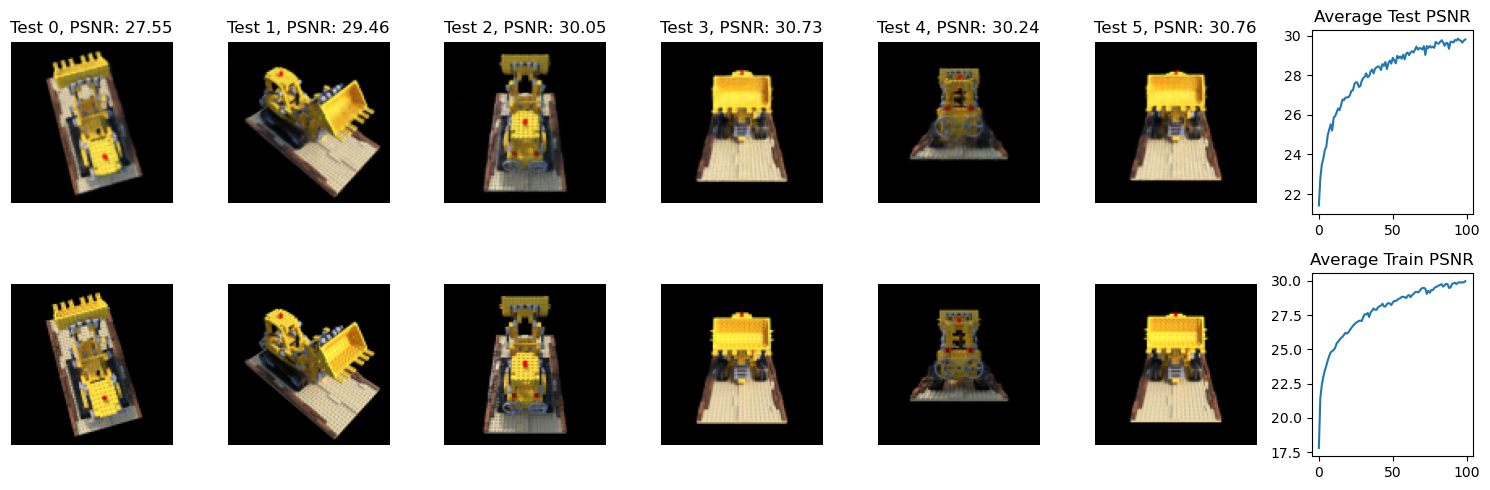

In [ ]:
# Initialize model and optimizer
model_coarse = NeRF(filter_size=128, L_embed=6).to(device)
model_fine = NeRF(filter_size=128, L_embed=6).to(device)
optimizer = optim.Adam(list(model_coarse.parameters()) + list(model_fine.parameters()), lr=5e-4)

# training parameters
N_epochs = 100
# number of coarse samples, number of fine samples
N_c, N_f = 32, 64

train_psnrs, test_psnrs = [], []
for epoch in range(N_epochs):
    
    # train
    avg_psnr, ray_count = 0.0, 0
    for rays_o, rays_d, rays_rgb in train_dataloader:    
        optimizer.zero_grad()
        
        # volume rendering
        rgb_c, rgb_f = render_rays(model_coarse, model_fine, rays_o, rays_d, near=2., far=6., N_c=N_c, N_f=N_f, rand=True)
        
        # loss computation
        loss_c = F.mse_loss(rgb_c, rays_rgb)
        loss_f = F.mse_loss(rgb_f, rays_rgb)
        loss = loss_c + loss_f
        
        # Backward pass        
        loss.backward()
        optimizer.step()

        # metric
        avg_psnr += (-10. * torch.log10(loss_f)).cpu().item()
        ray_count += 1
    
    # averge batch psnrs
    train_psnrs.append(avg_psnr / ray_count)
    
    # test
    with torch.no_grad():
        clear_output(wait=True)
        fig, axes = plt.subplots(2, 7, figsize=(15, 5))
        avg_psnr = 0.0
        for test_idx in range(len(test_images)):
            # test image
            testimg, testpose = test_images[test_idx], test_poses[test_idx]
            
            # volume rendering
            rays_o, rays_d = get_rays(K, testpose, H, W)
            _, rgb = render_rays(model_coarse, model_fine, rays_o, rays_d, near=2., far=6., N_c=N_c, N_f=N_f, rand=False)
            
            # PSNR computation
            test_loss = F.mse_loss(rgb, testimg)
            psnr = (-10. * torch.log10(test_loss)).cpu().item()
            avg_psnr += psnr

            # plot rendered images and ground-truth images
            axes[0,test_idx].set_title(f"Test {test_idx}, PSNR: {psnr:.2f}");
            axes[0,test_idx].imshow(rgb.cpu().numpy()); axes[0, test_idx].axis('off');
            axes[1,test_idx].imshow(testimg.cpu().numpy()); axes[1, test_idx].axis('off');
        
        # plot test psnr
        test_psnrs.append(avg_psnr / len(test_images))
        axes[0,6].plot(test_psnrs, label='Test')
        axes[0,6].set_title('Average Test PSNR')
        axes[1,6].plot(train_psnrs, label='Train')
        axes[1,6].set_title('Average Train PSNR')
        plt.tight_layout()
        plt.show()

## Interactive Visualization: Novel View Synthesis

After training, the MLP has "memorized" the scene's geometry and colors. To visualize this, we use an interactive tool that allows us to place a virtual camera anywhere on a sphere surrounding the object. We use **Spherical Coordinates** to define the camera's position relative to the center of the scene:

- **$\theta$ (Azimuth):** Rotates the camera horizontally around the object (left to right, $0^\circ$ to $360^\circ$).
- **$\phi$ (Elevation):** Moves the camera vertically (up and down, typically $-90^\circ$ to $90^\circ$).
- **Radius:** Adjusts the distance of the camera from the center (zoom in/out).
### How the tool works

1. **Coordinate Conversion:** The tool takes your slider values ($r, \theta, \phi$) and converts them into a standard $[4,4]$ Camera-to-World (c2w) matrix.
2. **Ray Generation:** Using the `get_rays` function we wrote earlier, it generates a new set of rays from this novel perspective.
3. **Inference:** These rays are passed through the Fine MLP (the most accurate network).
4. **Real-time Rendering:** The `render_rays` function applies volume rendering to produce the final image you see on the screen.


In [ ]:
%matplotlib inline
from ipywidgets import interactive, widgets


trans_t = lambda t: torch.tensor([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, t],
    [0, 0, 0, 1],
], dtype=torch.float32)

# Rotation about x-axis (phi)
rot_phi = lambda phi: torch.tensor([
    [1, 0, 0, 0],
    [0, torch.cos(phi), -torch.sin(phi), 0],
    [0, torch.sin(phi),  torch.cos(phi), 0],
    [0, 0, 0, 1],
], dtype=torch.float32)

# Rotation about y-axis (theta)
rot_theta = lambda th: torch.tensor([
    [torch.cos(th), 0, -torch.sin(th), 0],
    [0, 1, 0, 0],
    [torch.sin(th), 0,  torch.cos(th), 0],
    [0, 0, 0, 1],
], dtype=torch.float32)

def pose_spherical(theta, phi, radius):
    c2w = trans_t(radius)
    c2w = rot_phi(torch.tensor(phi / 180. * np.pi)) @ c2w
    c2w = rot_theta(torch.tensor(theta / 180. * np.pi)) @ c2w
    c2w = torch.tensor([
        [-1, 0, 0, 0],
        [ 0, 0, 1, 0],
        [ 0, 1, 0, 0],
        [ 0, 0, 0, 1],
    ], dtype=torch.float32) @ c2w
    return c2w.to(device)

def f(**kwargs):
    c2w = pose_spherical(**kwargs)
    rays_o, rays_d = get_rays(K, c2w[:3, :4], H, W)
    _, rgb = render_rays(model_fine, rays_o, rays_d, near=2., far=6., N_c=N_c, N_f=N_f, rand=False)
    img = rgb.detach().cpu().numpy()
    img = np.clip(img, 0, 1)

    
    plt.figure(2, figsize=(20, 6))
    plt.imshow(img)
    plt.show()

sldr = lambda v, mi, ma: widgets.FloatSlider(
    value=v,
    min=mi,
    max=ma,
    step=0.01,
)

names = [
    ['theta', [100., 0., 360.]],
    ['phi', [-30., -90., 0.]],
    ['radius', [4., 3., 5.]],
]

interactive_plot = interactive(f, **{s[0]: sldr(*s[1]) for s in names})
output = interactive_plot.children[-1]
output.layout.height = '350px'
interactive_plot


# Taking NeRF Further

We have built the "Classic" NeRF, but the field has advanced significantly since its publication. For a deep dive into these modern advances, check out our Survey Paper.

> [Neural Radiance Fields for the Real World: A Survey](https://arxiv.org/abs/2501.13104)

### Other resources
- [Nerfstudio](https://docs.nerf.studio/): The go-to modular PyTorch framework for swapping models and real-time training visualization.

- [Instant-NGP](https://github.com/NVlabs/instant-ngp): NVIDIA’s hash-encoding breakthrough; achieves photorealism in seconds.

- 3D Gaussian Splatting: A fast alternative using 3D "blobs" instead of an MLP; currently the state-of-the-art for real-time rendering.

- [Awesome-NeRF](https://github.com/awesome-NeRF/awesome-NeRF): A curated repository of essential papers and datasets.
